In [125]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [126]:
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [127]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.3100,34.1900,15.0000,"5,612.0000","1,283.0000","1,015.0000",472.0000,1.4936,"66,900.0000"
1,-114.4700,34.4000,19.0000,"7,650.0000","1,901.0000","1,129.0000",463.0000,1.8200,"80,100.0000"
2,-114.5600,33.6900,17.0000,720.0000,174.0000,333.0000,117.0000,1.6509,"85,700.0000"
3,-114.5700,33.6400,14.0000,"1,501.0000",337.0000,515.0000,226.0000,3.1917,"73,400.0000"
4,-114.5700,33.5700,20.0000,"1,454.0000",326.0000,624.0000,262.0000,1.9250,"65,500.0000"


In [128]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16995,-124.2600,40.5800,52.0000,"2,217.0000",394.0000,907.0000,369.0000,2.3571,"111,400.0000"
16996,-124.2700,40.6900,36.0000,"2,349.0000",528.0000,"1,194.0000",465.0000,2.5179,"79,000.0000"
16997,-124.3000,41.8400,17.0000,"2,677.0000",531.0000,"1,244.0000",456.0000,3.0313,"103,600.0000"
16998,-124.3000,41.8000,19.0000,"2,672.0000",552.0000,"1,298.0000",478.0000,1.9797,"85,800.0000"
16999,-124.3500,40.5400,52.0000,"1,820.0000",300.0000,806.0000,270.0000,3.0147,"94,600.0000"


In [129]:

print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Строк: 17000, Столбцов: 9


In [130]:
# Общая информация и статистика
df.info()
print(df.describe())

# Статистика по категориальным признакам (если есть)
object_cols = df.select_dtypes(include="object").columns
if len(object_cols) > 0:
    print(df.describe(include="object"))
else:
    print("Нет строковых колонок")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
        longitude    latitude  housing_median_age  total_rooms  \
count 17,000.0000 17,000.0000         17,000.0000  17,000.0000   
mean    -119.5621     35.6252             28.5894   2,643.6644   
std        2.0052      2.1373             12.5869   2,179.9471   
min     -124.3500     32.5400              1.0000

In [131]:
# Проверка пропущенных значений
print(df.isnull().sum())

# Детально с процентами
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропущено': missing, '%': missing_percent})
print(missing_df[missing_df['Пропущено'] > 0])

# Дубликаты
print(f"Дубликаты: {df.duplicated().sum()}")

# Типы данных
print(df.dtypes)

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64
Empty DataFrame
Columns: [Пропущено, %]
Index: []
Дубликаты: 0
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object


In [132]:
# Поиск выбросов методом IQR
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {outliers} выбросов")

longitude: 0 выбросов
latitude: 0 выбросов
housing_median_age: 0 выбросов
total_rooms: 1076 выбросов
total_bedrooms: 1074 выбросов
population: 1015 выбросов
households: 1032 выбросов
median_income: 563 выбросов
median_house_value: 895 выбросов


In [133]:
df_missing = df.copy()

# Удаление строк с пропусками
df_drop_rows = df_missing.dropna()
print(f"Строк осталось: {len(df_drop_rows)}")

# Удаление колонок с пропусками
df_drop_cols = df_missing.dropna(axis=1)
print(f"Колонок осталось: {df_drop_cols.shape[1]}")

# Удаление по порогу 50%
df_drop_thresh = df_missing.dropna(thresh=len(df_missing.columns) * 0.5)
print(f"Строк осталось (thresh 50%): {len(df_drop_thresh)}")

Строк осталось: 17000
Колонок осталось: 9
Строк осталось (thresh 50%): 17000


In [134]:
df_filled = df_missing.copy()

# Заполнение медианой
df_filled['median_income_median'] = df_filled['median_income'].fillna(df_filled['median_income'].median())
print(f"median_income: медиана = {df['median_income'].median():.4f}, пропусков осталось: {df_filled['median_income_median'].isnull().sum()}")

median_income: медиана = 3.5446, пропусков осталось: 0


In [135]:
# Расширенная статистика для числовых признаков
numeric_df = df.select_dtypes(include=[np.number])

advanced_stats = pd.DataFrame({
    'variance': numeric_df.var(),
    'skewness': numeric_df.skew(),
    'kurtosis': numeric_df.kurtosis()
})

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print(advanced_stats)

                              variance  skewness  kurtosis
longitude                       4.0207   -0.3040   -1.3223
latitude                        4.5682    0.4718   -1.1122
housing_median_age            158.4310    0.0649   -0.8008
total_rooms             4,752,169.2343    4.0027   29.5159
total_bedrooms            177,661.7877    3.3226   19.6928
population              1,317,566.4159    5.1872   80.8620
households                147,856.2771    3.3427   20.6926
median_income                   3.6411    1.6267    4.7641
median_house_value 13,452,233,601.4276    0.9730    0.3040


In [136]:
# Перцентили: 5%, 25%, 50%, 75%, 95%
percentiles = [0.05, 0.25, 0.50, 0.75, 0.95]
percentile_labels = ['p5', 'p25', 'p50', 'p75', 'p95']

percentile_stats = pd.DataFrame()
for col in numeric_df.columns:
    for p, label in zip(percentiles, percentile_labels):
        percentile_stats.loc[col, label] = numeric_df[col].quantile(p)

print(percentile_stats)

# Пример интерпретации для median_house_value
target_col = 'median_house_value'
print(f"\n{target_col}: p5=${percentile_stats.loc[target_col, 'p5']:,.0f}, p95=${percentile_stats.loc[target_col, 'p95']:,.0f}")
print(f"IQR = ${percentile_stats.loc[target_col, 'p75'] - percentile_stats.loc[target_col, 'p25']:,.0f}")

                            p5          p25          p50          p75  \
longitude            -122.4700    -121.7900    -118.4900    -118.0000   
latitude               32.8200      33.9300      34.2500      37.7200   
housing_median_age      8.0000      18.0000      29.0000      37.0000   
total_rooms           626.9500   1,462.0000   2,127.0000   3,151.2500   
total_bedrooms        138.0000     297.0000     434.0000     648.2500   
population            350.9500     790.0000   1,167.0000   1,721.0000   
households            126.0000     282.0000     409.0000     605.2500   
median_income           1.6034       2.5664       3.5446       4.7670   
median_house_value 66,000.0000 119,400.0000 180,400.0000 265,000.0000   

                            p95  
longitude             -117.0700  
latitude                38.9600  
housing_median_age      52.0000  
total_rooms          6,269.0500  
total_bedrooms       1,283.0000  
population           3,297.0500  
households           1,172.1000

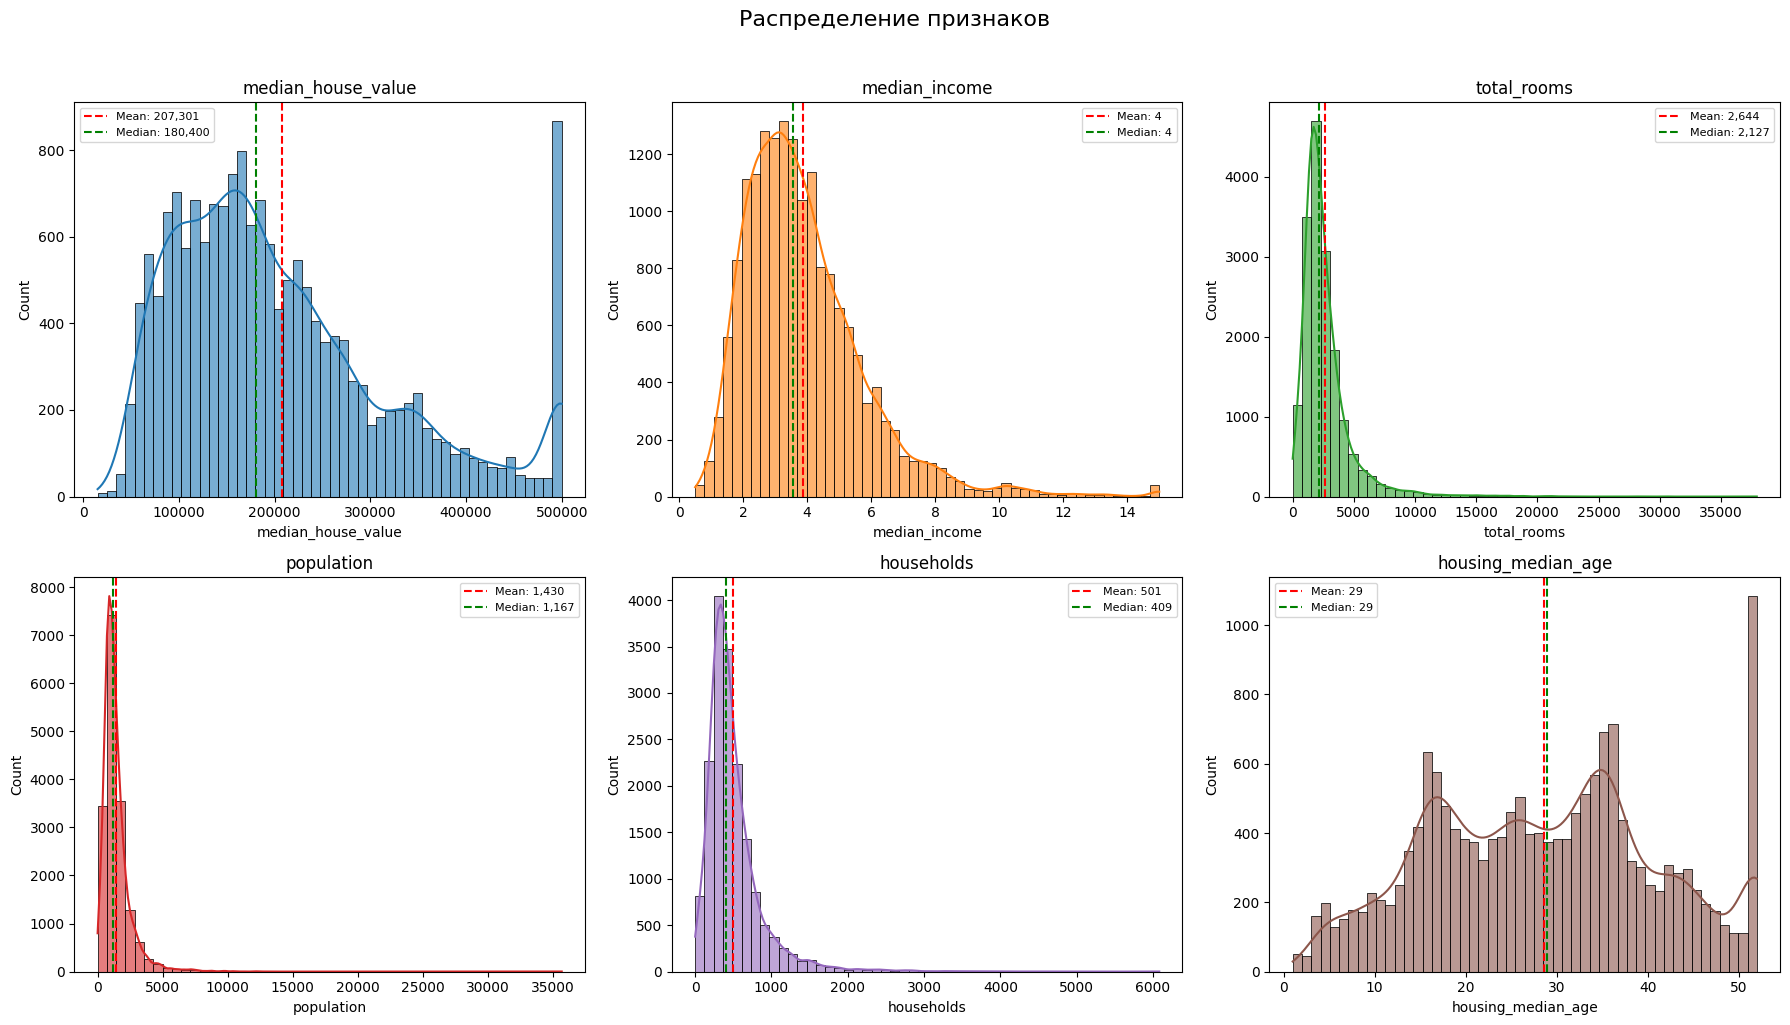

In [137]:
# Гистограммы с KDE для числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

numeric_cols = ['median_house_value', 'median_income', 'total_rooms',
                'population', 'households', 'housing_median_age']

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx],
                 color=f'C{idx}', alpha=0.6, bins=50)

    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.0f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:,.0f}')

    axes[idx].set_title(f'{col}', fontsize=12)
    axes[idx].legend(fontsize=8)

plt.suptitle('Распределение признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

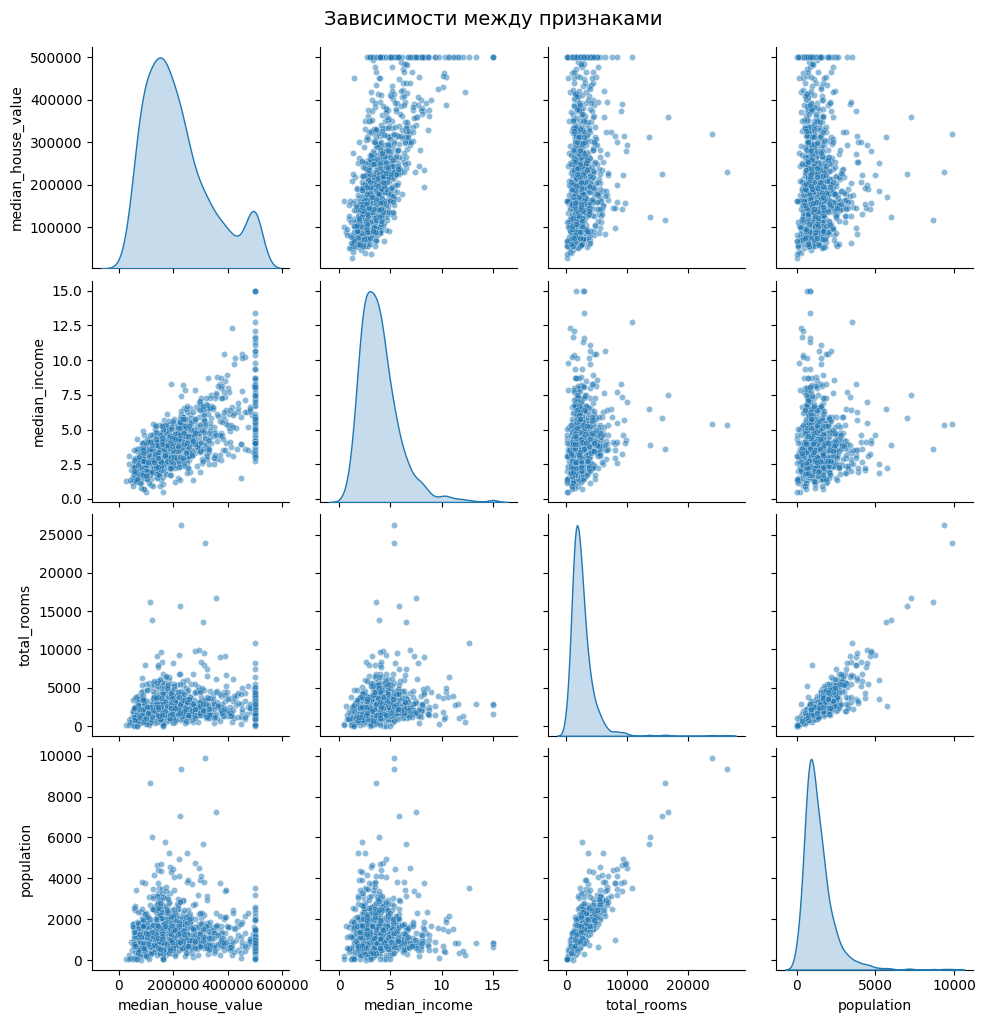

In [138]:
# Pairplot для обзора зависимостей (выбираем 4 признака)
pairplot_cols = ['median_house_value', 'median_income', 'total_rooms', 'population']
df_sample = df.sample(min(1000, len(df)), random_state=42)

g = sns.pairplot(df_sample[pairplot_cols],
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Зависимости между признаками', fontsize=14, y=1.02)

plt.show()


Выбросы по методу IQR:
median_house_value: 895 (5.3%)
median_income: 563 (3.3%)
total_rooms: 1076 (6.3%)
population: 1015 (6.0%)


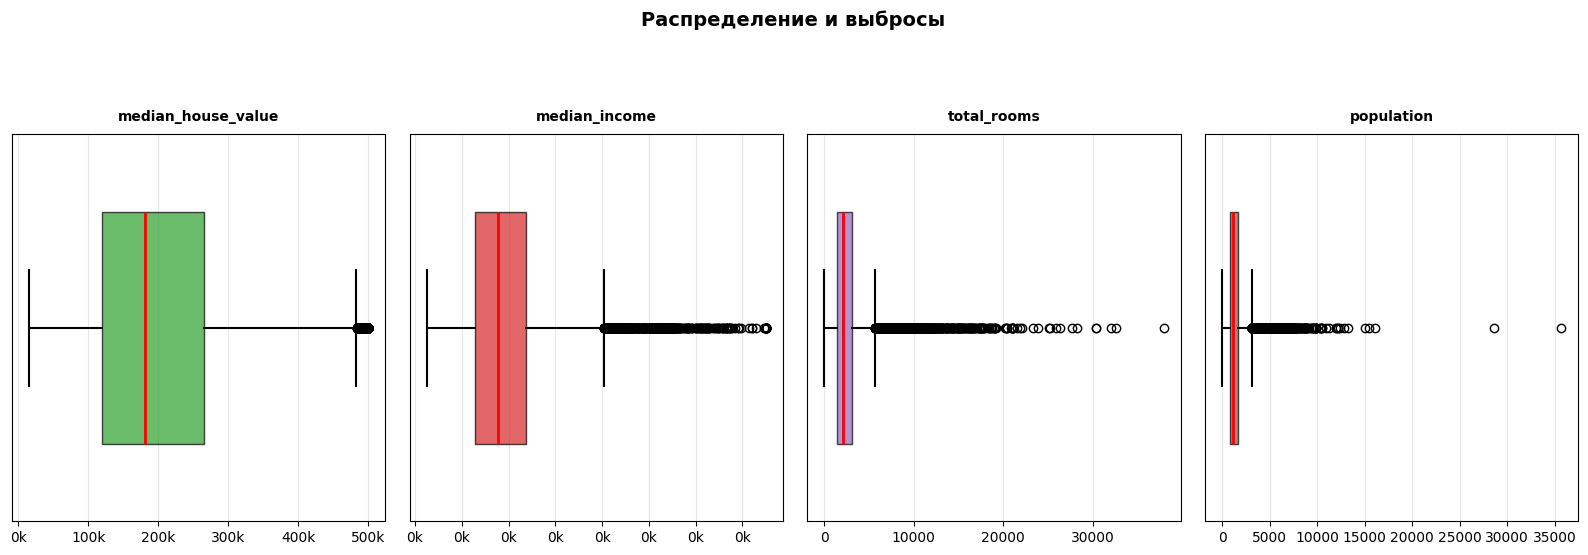

In [139]:
# Box Plot для поиска выбросов
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

cols_to_check = ['median_house_value', 'median_income', 'total_rooms', 'population']

for idx, col in enumerate(cols_to_check):
    bp = axes[idx].boxplot(df[col],
                           vert=False,
                           patch_artist=True,
                           widths=0.6,
                           boxprops=dict(facecolor=f'C{idx+2}', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           whiskerprops=dict(linewidth=1.5),
                           capprops=dict(linewidth=1.5))

    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold', pad=10)
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].tick_params(axis='y', left=False, labelleft=False)

    # Форматируем ось X
    if col in ['median_house_value', 'median_income']:
        axes[idx].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))

plt.suptitle('Распределение и выбросы', fontsize=14, fontweight='bold', y=1.1)
plt.tight_layout()

# Статистика выбросов
print("\nВыбросы по методу IQR:")
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

plt.show()

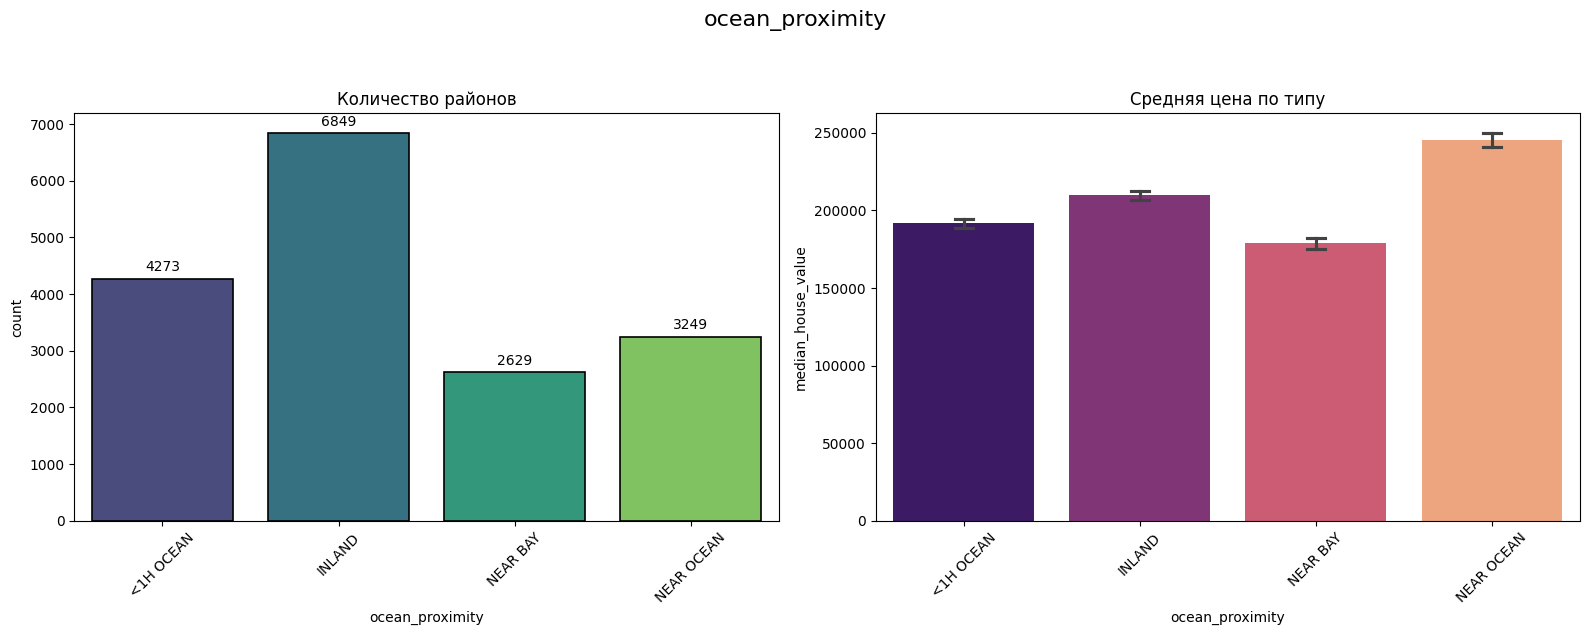

In [140]:
# Создаём ocean_proximity если нет
if 'ocean_proximity' not in df.columns:
    def assign_zone(lon):
        if lon < -122: return 'NEAR OCEAN'
        elif lon < -121: return 'NEAR BAY'
        elif lon < -118: return 'INLAND'
        else: return '<1H OCEAN'
    df['ocean_proximity'] = df['longitude'].apply(assign_zone)

# Count Plot и Bar Plot для категориального признака
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='ocean_proximity', ax=axes[0],
              palette='viridis', edgecolor='black', linewidth=1.2)
axes[0].set_title('Количество районов', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)

sns.barplot(data=df, x='ocean_proximity', y='median_house_value',
            ax=axes[1], palette='magma', errorbar='ci', capsize=0.1)
axes[1].set_title('Средняя цена по типу', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('ocean_proximity', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('bar_count_plots.png', dpi=300, bbox_inches='tight')
plt.show()


Сильные корреляции:
median_income ↔ median_house_value: 0.692
population ↔ total_rooms: 0.860
households ↔ total_rooms: 0.919
households ↔ population: 0.909


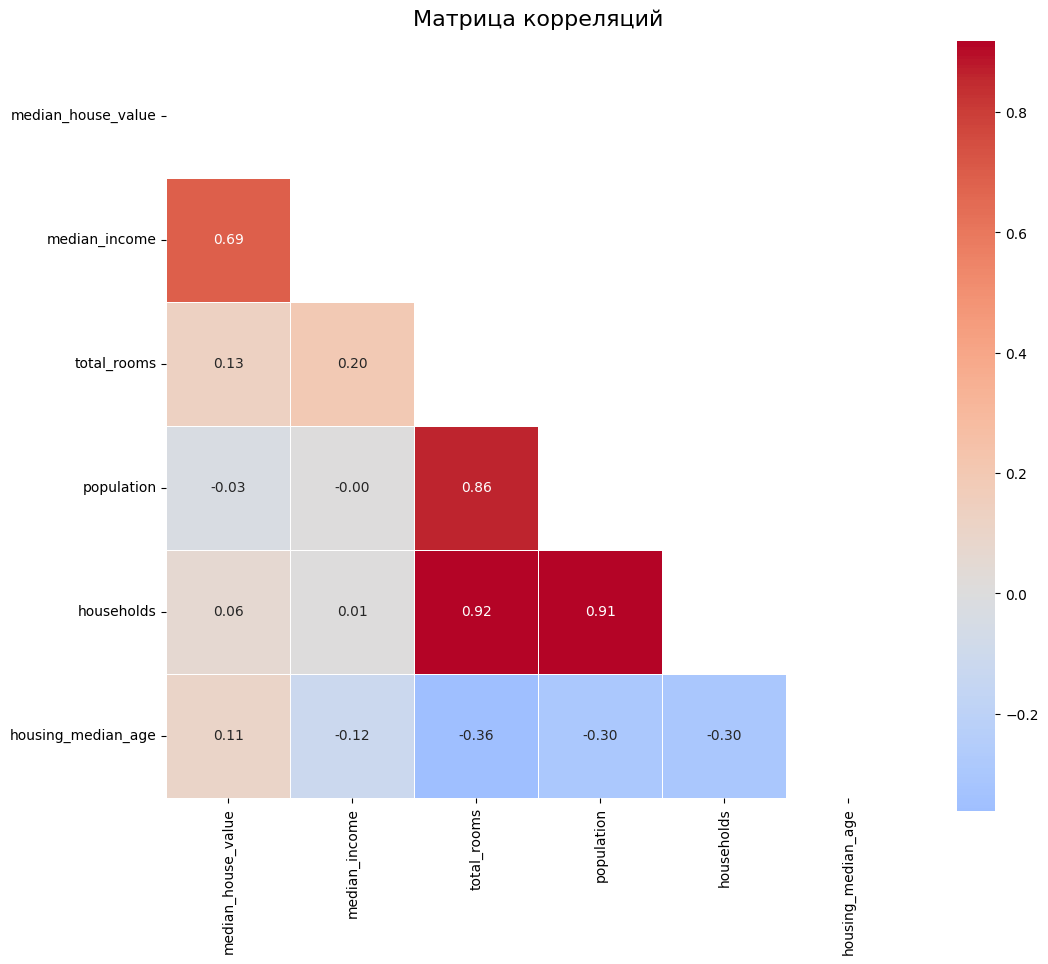

In [141]:
# Heatmap корреляций
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Матрица корреляций', fontsize=16, pad=20)

# Вывод сильных корреляций (>0.5)
print("\nСильные корреляции:")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5:
            print(f"{corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

plt.show()